RESULTADOS DETERMINÍSTICOS
WACC: 11.24%
VAN Base: S/ 10,578.12
TIR Base: 15.38%
Payback: 4 años

RESULTADOS MONTE CARLO
VAN promedio simulado: S/ 10,659.85
Probabilidad de pérdida (VAN < 0): 18.03%


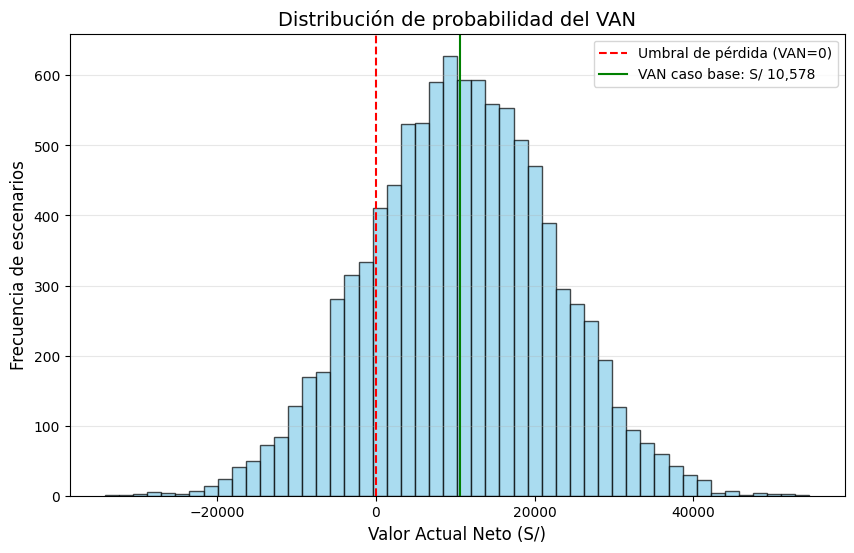

In [1]:
#PROYECTO: Corporate_Finance_and_Valuation
#Elaborado por: Ricardo Alexis Sifuentes Zevallos
#Objetivo: Integración de métricas determinísticas y estocásticas (Monte Carlo)

try:
    import numpy_financial as npf
except ImportError:
    !pip install -q numpy-financial
    import numpy_financial as npf

import numpy as np
import matplotlib.pyplot as plt

#1.CONFIGURACIÓN DE SUPUESTOS (INPUTS)
inversion_inicial = -100000
horizonte = 5
tasa_impuesto = 0.30
ingresos_esperados = 65000
costos_esperados = 22000

#Estructura de capital (WACC)
peso_deuda = 0.40
peso_patrimonio = 0.60
costo_deuda = 0.08
costo_patrimonio = 0.15

#2. CÁLCULO DEL WACC
#El WACC representa el retorno mínimo exigido por los inversionistas
wacc = (peso_patrimonio * costo_patrimonio) + (peso_deuda * costo_deuda * (1 - tasa_impuesto))

#3. MODELO DETERMINÍSTICO (CASO BASE)
def calcular_metricas_base(ing, cost, inv, tax, r_wacc):
    flujo_op = (ing - cost) * (1 - tax)
    v_flujos = np.array([inv] + [flujo_op] * horizonte)

    van = npf.npv(r_wacc, v_flujos)
    tir = npf.irr(v_flujos)

    #Cálculo de payback
    acumulado = 0
    pb = None
    for t, f in enumerate(v_flujos):
        acumulado += f
        if acumulado >= 0:
            pb = t
            break
    return van, tir, pb, v_flujos

van_base, tir_base, pb_base, flujos_base = calcular_metricas_base(
    ingresos_esperados, costos_esperados, inversion_inicial, tasa_impuesto, wacc
)

#4.SIMULACIÓN DE MONTE CARLO (ANÁLISIS DE RIESGO)
#El análisis tradicional es incompleto, pero Monte Carlo permite medir riesgo explícitamente
n_sim = 10000
vol_ingresos = 0.15  # 15% volatilidad
vol_costos = 0.10    # 10% volatilidad

np.random.seed(777) # Para reproducibilidad

#Simulación de variables inciertas
ingresos_sim = np.random.normal(ingresos_esperados, vol_ingresos * ingresos_esperados, (n_sim, horizonte))
costos_sim = np.random.normal(costos_esperados, vol_costos * costos_esperados, (n_sim, horizonte))

#Cálculo de flujos y VAN para 10,000 escenarios
flujos_sim = (ingresos_sim - costos_sim) * (1 - tasa_impuesto)
van_simulado = []

for i in range(n_sim):
    f_total = np.concatenate([[inversion_inicial], flujos_sim[i]])
    van_simulado.append(npf.npv(wacc, f_total))

van_simulado = np.array(van_simulado)

#5.RESULTADOS Y VISUALIZACIÓN
van_promedio = van_simulado.mean()
prob_perdida = np.mean(van_simulado < 0)

print(f"RESULTADOS DETERMINÍSTICOS")
print(f"WACC: {wacc:.2%}")
print(f"VAN Base: S/ {van_base:,.2f}")
print(f"TIR Base: {tir_base:.2%}")
print(f"Payback: {pb_base} años")
print(f"\nRESULTADOS MONTE CARLO")
print(f"VAN promedio simulado: S/ {van_promedio:,.2f}")
print(f"Probabilidad de pérdida (VAN < 0): {prob_perdida:.2%}")

#Gráfico VAN
plt.figure(figsize=(10, 6))
plt.hist(van_simulado, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', label='Umbral de pérdida (VAN=0)')
plt.axvline(van_base, color='green', linestyle='-', label=f'VAN caso base: S/ {van_base:,.0f}')
plt.title("Distribución de probabilidad del VAN", fontsize=14)
plt.xlabel("Valor Actual Neto (S/)", fontsize=12)
plt.ylabel("Frecuencia de escenarios", fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()